In [16]:
import torch
import matplotlib.pyplot as plt
g=torch.Generator().manual_seed(114514)

In [20]:
class Tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out
    def parameters(self):
        return []

Text(0.5, 1.0, 'activation distribution')

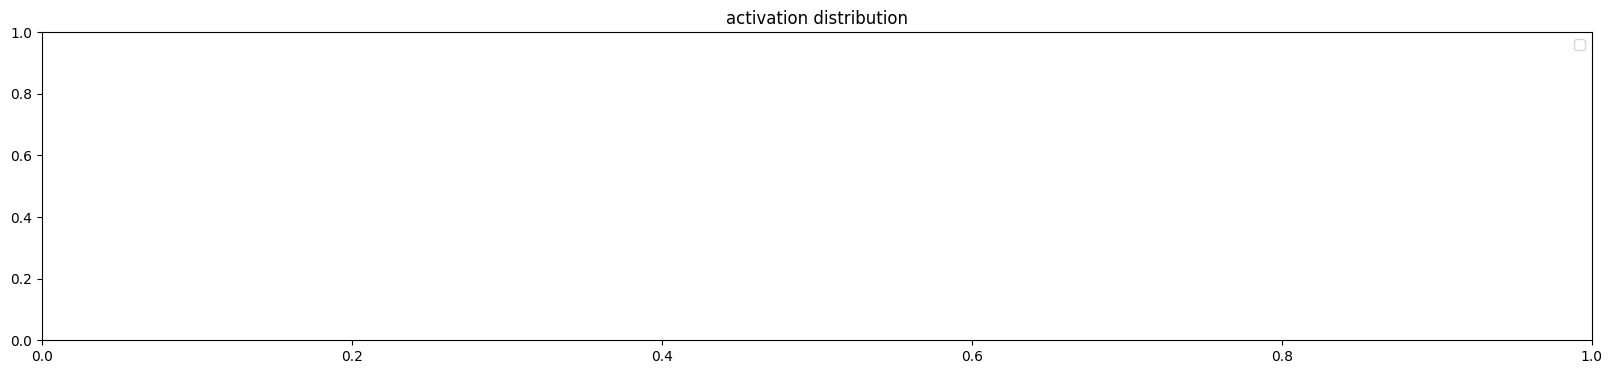

In [14]:
layers=[]
plt.figure(figsize=(20,4))
legends=[]
for i,layer in enumerate(layers[:-1]):
    if isinstance(layer,Tanh):
        t=layer.out
        print('layer %d (%10s):mean %+.2f,std %.2f,saturated: %.2f%',
                i,layer.__class__.__name__,t.mean(),t.std(),
                (t.abs()>0.97).float().mean()*100)
        hy,hx=torch.histogram(t,density=True)
        plt.plot(hx[:-1].detach(),hy.detach())
        legends.append(f'layer{i}({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')


In [19]:
class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weight=torch.randn((fan_in,fan_out),generator=g)/fan_in**0.5
        self.bias=torch.zeros(fan_out) if bias else None
    def __call__(self,X):
        self.out=X@self.weight
        if self.bias is not None:
            self.out+=self.bias
        return self.out
    def parameters(self):
        return [self.weight]+([]if self.bias is None else [self.bias])

        

In [22]:

vocab_size=27
block_size=3
n_emb=10
n_hidden=100
layers=[
    Linear(n_emb*block_size,n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),Tanh(),
     Linear(n_hidden,n_hidden),Tanh(),
      Linear(n_hidden,n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]


In [ ]:
class BatchNormal1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps=eps
        self.momentum=momentum
        self.training=True
        self.gamma=torch.ones(dim)
        self.beta=torch.zeros(dim)
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)
    def __call__(self,x):
        if self.training:
            xmean=x.mean(0,keepdim=True)
            xvar=x.var(0,keepdim=True)
        else :
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/torch.sqrt(xvar+self.eps)
        self.out=self.gamma*xhat+self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
                self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar
        return self.out
    def parameters(self):
        return [self.gamma,self.beta]
        
        

In [27]:
words=open("names.txt","r").read().splitlines()   

stoi={s:ord(s)-ord('a')+1 for s in sorted(set(''.join(words)))}
stoi['.']=0
itos={i:s for s,i in stoi.items()}

def build_dataset(words):
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y

X,Y=build_dataset(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

In [30]:
g=torch.Generator().manual_seed(114514)
C=torch.randn((27,10),generator=g)

In [ ]:
import torch.nn.functional  as F
max_steps=200000
batch_size=32
lossi=[]
ud=[] # update/data ratio

parameters=[p for layer in layers for p in layer.parameters()]+[C]
for p in parameters:
    p.requires_grad=True
for i in range(max_steps):
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)
    # backward
    for layer in layers:
        layer.out.retain_grad()
    
    for p in parameters:
        p.grad=None
    loss.backward()
    lr =0.1 if i<150000 else 0.01
    for p in parameters:
        p.data+=-lr*p.grad
    if i%10000 ==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item()  
                   for p in parameters]) 


      0/ 200000:3.3405
  10000/ 200000:2.3923
  20000/ 200000:1.8847
  30000/ 200000:1.9148
  40000/ 200000:2.1823
  50000/ 200000:1.7899
  60000/ 200000:2.2608
  70000/ 200000:2.2300
  80000/ 200000:2.1589
  90000/ 200000:1.8659
 100000/ 200000:1.5989
